In [1]:
!pip install kagglehub[pandas-datasets]

In [2]:
# Install (only once)
!pip install kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter

# Correct file path
file_path = "fer2013.csv"

# Load dataset
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "deadskull7/fer2013",
    file_path
)

# Preview
print("First 5 records:")
print(df.head())

/tmp/ipykernel_699/2135557870.py:11: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'fer2013' dataset.
First 5 records:
   emotion                                             pixels     Usage
0        0  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...  Training
1        0  151 150 147 155 148 133 111 140 170 174 182 15...  Training
2        2  231 212 156 164 174 138 161 173 182 200 106 38...  Training
3        4  24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...  Training
4        6  4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...  Training


In [6]:
import numpy as np
import pandas as pd
import cv2
import os

# Load dataset
# df = pd.read_csv('/root/.cache/kagglehub/datasets/deadskull7/fer2013/versions/1/fer2013.csv')

# Create folders
base_path = "data"
os.makedirs(base_path, exist_ok=True)

emotions = {
    0: "angry",
    1: "disgust",
    2: "fear",
    3: "happy",
    4: "sad",
    5: "surprise",
    6: "neutral"
}

for emotion in emotions.values():
    os.makedirs(f"{base_path}/{emotion}", exist_ok=True)

# Convert pixels → image
for i, row in df.iterrows():
    pixels = np.array(row['pixels'].split(), dtype='uint8')
    img = pixels.reshape(48, 48)

    label = emotions[row['emotion']]
    cv2.imwrite(f"{base_path}/{label}/{i}.jpg", img)

print("Images created ✅")

Images created ✅


# Load Dataset

In [7]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((48, 48)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder("data", transform=transform)
train_loader = DataLoader(dataset, batch_size=64, shuffle=True)

print("Classes:", dataset.classes)

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


# Build CNN Model

In [8]:
import torch.nn as nn
import torch.nn.functional as F

class EmotionCNN(nn.Module):
    def __init__(self):
        super(EmotionCNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 10 * 10, 128)
        self.fc2 = nn.Linear(128, 7)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = x.view(-1, 64 * 10 * 10)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

model = EmotionCNN()
print(model)

EmotionCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=6400, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=7, bias=True)
)


# Train Model

In [9]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(5):  # keep small for 1-day project
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

print("Training Done ✅")

Epoch 1, Loss: 921.2989
Epoch 2, Loss: 822.9811
Epoch 3, Loss: 766.5925
Epoch 4, Loss: 726.4525
Epoch 5, Loss: 692.4267
Training Done ✅


# Save Model

In [10]:
torch.save(model.state_dict(), "emotion_model.pth")

# Real-Time Webcam Prediction

In [ ]:
!pip install opencv-python

In [ ]:
import cv2
import torch

model.load_state_dict(torch.load("emotion_model.pth"))
model.eval()

emotion_labels = ['angry','disgust','fear','happy','sad','surprise','neutral']

cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()

    if not ret or frame is None:
        print("Error: Failed to capture frame from camera")
        break  # or continue, depending on your logic

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    face = cv2.resize(gray, (48, 48))

    face = face / 255.0
    face = torch.tensor(face).float().unsqueeze(0).unsqueeze(0)

    with torch.no_grad():
        output = model(face)
        _, pred = torch.max(output, 1)
        label = emotion_labels[pred.item()]

    cv2.putText(frame, label, (50, 50),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

    cv2.imshow("Emotion Detector", frame)

    if cv2.waitKey(1) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()

Error: Failed to capture frame from camera


In [ ]:
!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!bzip2 -d shape_predictor_68_face_landmarks.dat.bz2

--2026-04-09 16:34:24--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2026-04-09 16:34:24--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  37.5MB/s    in 1.6s    

2026-04-09 16:34:26 (37.5 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]



# Colab to upload image

Saving pic3.jpg to pic3.jpg


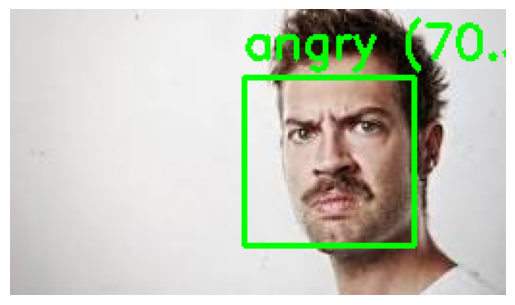

In [ ]:
import cv2
import torch
from google.colab import files
import numpy as np
from matplotlib import pyplot as plt
import dlib

import dlib

shape_predictor_path = "shape_predictor_68_face_landmarks.dat"
predictor = dlib.shape_predictor(shape_predictor_path)

# -------------------
# Load model
# -------------------
device = torch.device("cpu")
model.load_state_dict(torch.load("emotion_model.pth", map_location=device))
model.to(device)
model.eval()

emotion_labels = ['angry','disgust','fear','happy','sad','surprise','neutral']

# -------------------
# Load face detector & shape predictor for alignment
# -------------------
face_detector = dlib.get_frontal_face_detector()
# Download or upload shape predictor if not already in Colab
# You can get it from: http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
shape_predictor_path = "shape_predictor_68_face_landmarks.dat"
predictor = dlib.shape_predictor(shape_predictor_path)

def align_face(img, rect):
    """Align face using eyes position"""
    landmarks = predictor(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), rect)
    left_eye = (landmarks.part(36).x, landmarks.part(36).y)
    right_eye = (landmarks.part(45).x, landmarks.part(45).y)

    # Compute the angle between eyes
    dy = right_eye[1] - left_eye[1]
    dx = right_eye[0] - left_eye[0]
    angle = np.degrees(np.arctan2(dy, dx))

    # Center between eyes
    eyes_center = ((left_eye[0]+right_eye[0])//2, (left_eye[1]+right_eye[1])//2)

    # Rotation matrix
    M = cv2.getRotationMatrix2D(eyes_center, angle, scale=1)
    aligned_img = cv2.warpAffine(img, M, (img.shape[1], img.shape[0]))
    return aligned_img

# -------------------
# Upload images
# -------------------
uploaded = files.upload()

for filename in uploaded.keys():
    file_bytes = np.frombuffer(uploaded[filename], np.uint8)
    img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_detector(gray)

    if len(faces) == 0:
        print(f"No faces detected in {filename}")
        continue

    for rect in faces:
        # Align face
        aligned_img = align_face(img, rect)

        # Crop aligned face
        x, y, w, h = rect.left(), rect.top(), rect.width(), rect.height()
        face = cv2.cvtColor(aligned_img[y:y+h, x:x+w], cv2.COLOR_BGR2GRAY)

        # Histogram equalization
        face = cv2.equalizeHist(face)

        # Resize for model
        face = cv2.resize(face, (48, 48))
        face = face / 255.0
        face_tensor = torch.tensor(face).float().unsqueeze(0).unsqueeze(0).to(device)

        # Predict emotion
        with torch.no_grad():
            output = model(face_tensor)
            probabilities = torch.softmax(output, dim=1)
            confidence, pred = torch.max(probabilities, 1)
            label = emotion_labels[pred.item()]

        # Draw rectangle & label
        cv2.rectangle(img, (x, y), (x+w, y+h), (0,255,0), 2)
        cv2.putText(img, f"{label} ({confidence.item()*100:.1f}%)",
                    (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)

    # Show image
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()